Import **Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

Load Data

In [2]:
fact = pd.read_csv(
    "https://raw.githubusercontent.com/DuaA-A/Enterprise-E-Commerce-Predictive-Analytics/refs/heads/main/Medallion%20Architecture/Gold%20Layer/fact_sales.csv"
)

product = pd.read_csv(
    "https://raw.githubusercontent.com/DuaA-A/Enterprise-E-Commerce-Predictive-Analytics/refs/heads/main/Medallion%20Architecture/Gold%20Layer/dim_product.csv"
)

market = pd.read_csv(
    "https://raw.githubusercontent.com/DuaA-A/Enterprise-E-Commerce-Predictive-Analytics/refs/heads/main/Medallion%20Architecture/Gold%20Layer/dim_marketplace.csv"
)

date = pd.read_csv(
    "https://raw.githubusercontent.com/DuaA-A/Enterprise-E-Commerce-Predictive-Analytics/refs/heads/main/Medallion%20Architecture/Gold%20Layer/dim_date.csv"
)

Merge Tables

In [3]:
df = fact.merge(product,on="Product_Key")
df = df.merge(market,on="Marketplace_Key")
df = df.merge(date,on="Date_Key")

Dataset Overview

In [4]:
print("="*60)
print("Marketing Dataset Overview")
print("="*60)

print(f"Dataset Shape : {df.shape}")

print("\nFirst 5 Rows")
display(df.head())

print("\nDataset Information")
df.info()

Marketing Dataset Overview
Dataset Shape : (13323, 48)

First 5 Rows


,Sales_Key,Date_Key,Marketplace_Key,Product_Key,Account Title_x,Taxes,Orders,Units,Refunded,Refund %,...,Account Title_y,Date,Day,Month,Month_Name,Quarter,Year,Week_Of_Year,Day_Name,Is_Weekend
0,1,1,1,1,[ UK ] Aava,-50.34,17,17,0,0.0,...,[ UK ] Aava,2020-10-01,1,10,October,4,2020,40,Thursday,False
1,2,2,1,1,[ UK ] Aava,-58.89,20,20,0,0.0,...,[ UK ] Aava,2020-10-02,2,10,October,4,2020,40,Friday,False
2,3,3,1,1,[ UK ] Aava,-72.41,18,24,0,0.0,...,[ UK ] Aava,2020-10-03,3,10,October,4,2020,40,Saturday,True
3,4,4,1,1,[ UK ] Aava,-41.43,13,14,0,0.0,...,[ UK ] Aava,2020-10-04,4,10,October,4,2020,40,Sunday,True
4,5,5,1,1,[ UK ] Aava,-47.04,16,16,0,0.0,...,[ UK ] Aava,2020-10-05,5,10,October,4,2020,41,Monday,False



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13323 entries, 0 to 13322
Data columns (total 48 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sales_Key         13323 non-null  int64  
 1   Date_Key          13323 non-null  int64  
 2   Marketplace_Key   13323 non-null  int64  
 3   Product_Key       13323 non-null  int64  
 4   Account Title_x   13323 non-null  object 
 5   Taxes             13323 non-null  float64
 6   Orders            13323 non-null  int64  
 7   Units             13323 non-null  int64  
 8   Refunded          13323 non-null  int64  
 9   Refund %          13323 non-null  float64
 10  Unit Session %    13323 non-null  float64
 11  Promo Units       13323 non-null  int64  
 12  Organic Units     13323 non-null  int64  
 13  Per Unit Revenue  13323 non-null  float64
 14  Revenue           13323 non-null  float64
 15  COGS              13323 non-null  float64
 16  FBA Fees          1

Marketing Statistics

In [5]:


marketing_cols = [
    "Sessions",
    "Clicks",
    "Impressions",
    "PPC Cost",
    "PPC Sales",
    "Organic Units",
    "PPC Conv",
    "Unit Session %"
]

stats = df[marketing_cols].describe().T

display(stats)

,count,mean,std,min,25%,50%,75%,max
Sessions,13323.0,20.968025,41.504721,0.00,0.00,0.0000,25.00,431.00
Clicks,13323.0,15.582376,25.220657,0.00,2.00,7.0000,18.00,713.00
Impressions,13323.0,4165.734819,6593.383509,0.00,537.00,1917.0000,5036.50,121882.00
PPC Cost,13323.0,-15.246775,26.139957,-1064.85,-17.23,-6.3300,-1.14,0.00
PPC Sales,13323.0,51.895073,94.217849,0.00,0.00,18.1700,63.61,2875.44
Organic Units,13323.0,13.284095,20.224256,0.00,3.00,7.0000,16.00,974.00
PPC Conv,13323.0,0.144013,0.258420,0.00,0.00,0.0769,0.20,6.00
Unit Session %,13323.0,0.134443,0.221282,0.00,0.00,0.0000,0.25,7.00


#KPIS



 Total Sessions


In [6]:
total_sessions = df['Sessions'].sum()

print(f"Total Sessions: {total_sessions:,.0f}")

Total Sessions: 279,357


Average CTR

In [7]:
avg_ctr = (
    df['Clicks'].sum() / df['Impressions'].sum() * 100
    if df['Impressions'].sum() != 0 else 0
)

print(f"Average CTR: {avg_ctr:.2f}%")

Average CTR: 0.37%


Total PPC Spend

In [8]:
total_ppc_spend = df['PPC Cost'].sum()

print(f"Total PPC Spend: ${total_ppc_spend:,.2f}")

Total PPC Spend: $-203,132.78


Total PPC Sales

In [9]:
total_ppc_sales = df['PPC Sales'].sum()

print(f"Total PPC Sales: ${total_ppc_sales:,.2f}")

Total PPC Sales: $691,398.06


Average Conversion Rate

In [10]:
avg_conversion_rate = df['Unit Session %'].mean()

print(f"Average Conversion Rate: {avg_conversion_rate:.2f}%")

Average Conversion Rate: 0.13%


#Correlation

Marketing Correlation Matrix

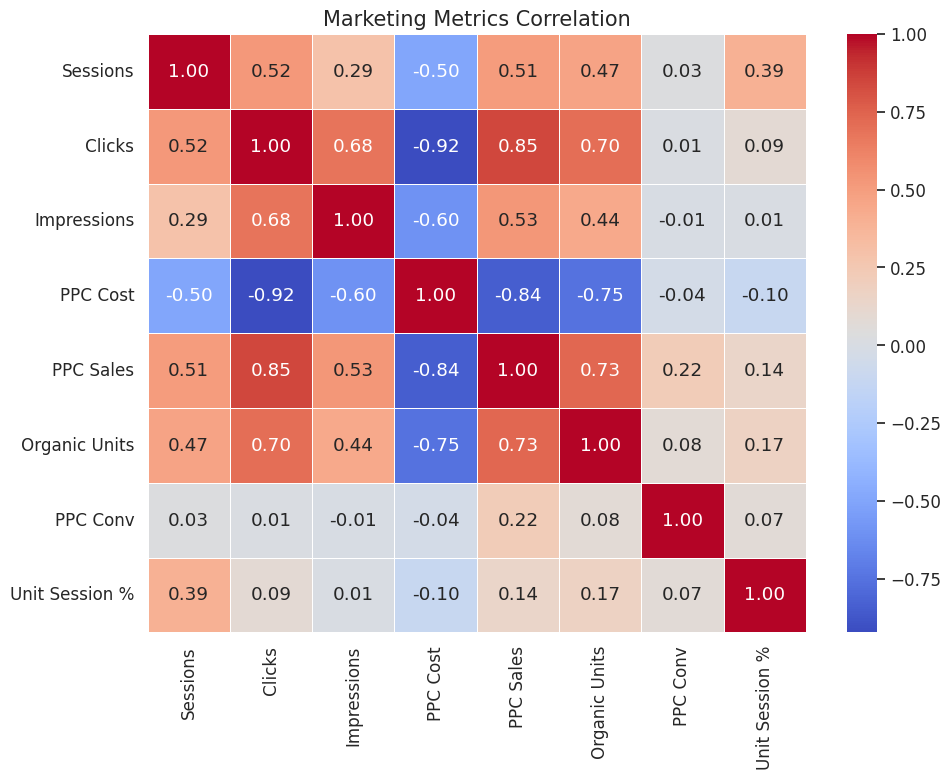

In [11]:


plt.figure(figsize=(10,8))

corr = df[marketing_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Marketing Metrics Correlation", fontsize=15)

plt.tight_layout()

plt.show()

#Charts


Top 10 Products by PPC Sales

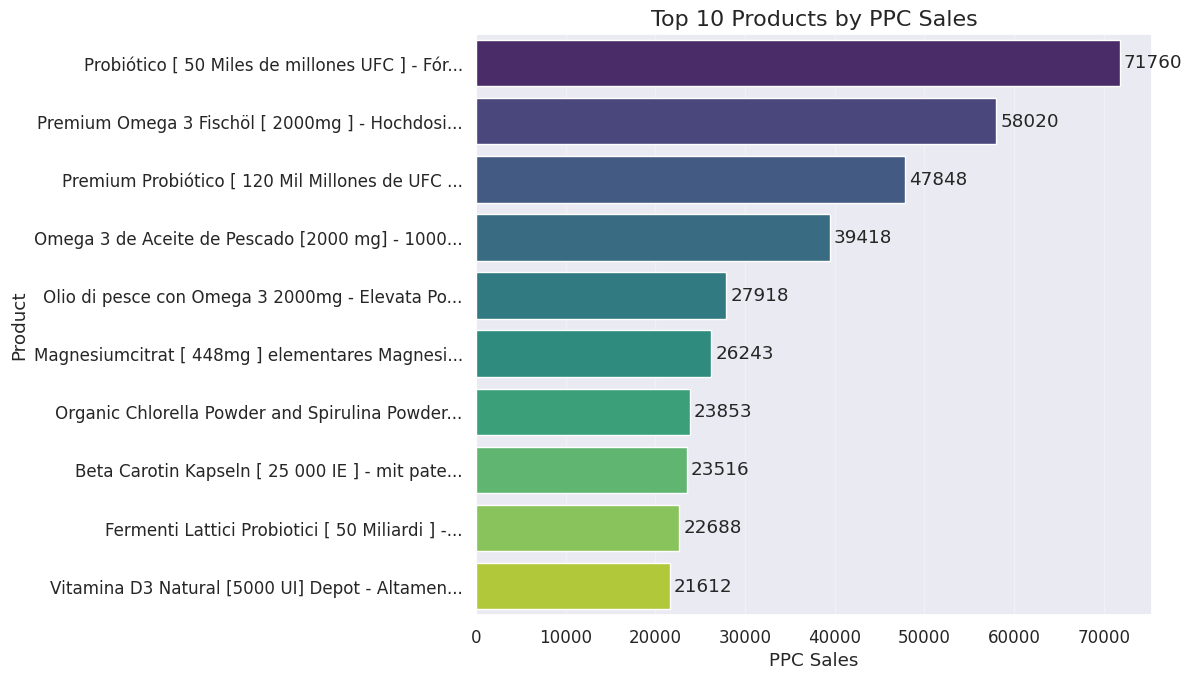

In [12]:
top_products = (
    df.groupby("Title", as_index=False)["PPC Sales"]
      .sum()
      .sort_values(by="PPC Sales", ascending=False)
      .head(10)
)


top_products["Short Title"] = top_products["Title"].apply(
    lambda x: x[:45] + "..." if len(x) > 45 else x
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_products,
    x="PPC Sales",
    y="Short Title",
    hue="Short Title",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Top 10 Products by PPC Sales", fontsize=16)
plt.xlabel("PPC Sales")
plt.ylabel("Product")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

 Traffic vs Conversion Quadrants

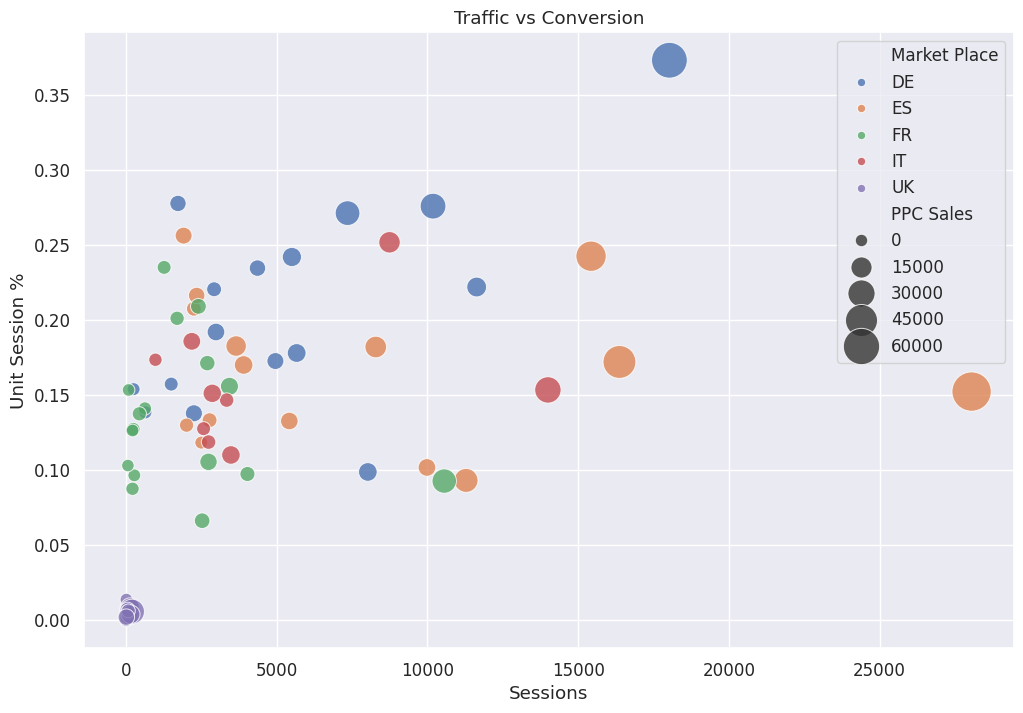

In [13]:
traffic = df.groupby("SKU").agg({
    "Sessions":"sum",
    "Unit Session %":"mean",
    "PPC Sales":"sum",
    "Market Place":"first"
}).reset_index()

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=traffic,
    x="Sessions",
    y="Unit Session %",
    hue="Market Place",
    size="PPC Sales",
    sizes=(80,800),
    alpha=0.8
)

plt.title("Traffic vs Conversion")
plt.xlabel("Sessions")
plt.ylabel("Unit Session %")
plt.grid(True)

plt.show()

Halo Effect

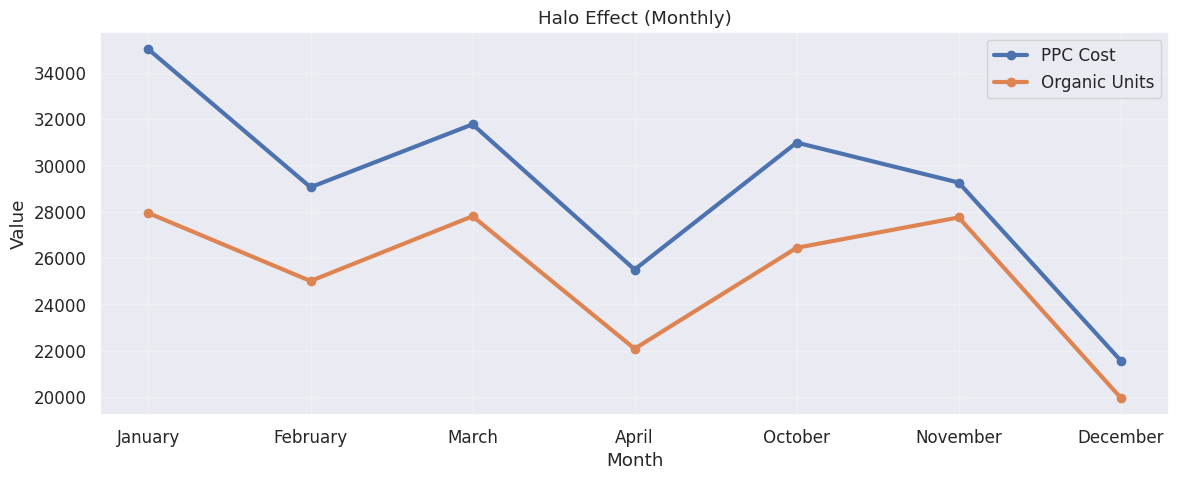

In [14]:
halo = df.groupby("Month_Name").agg({
    "PPC Cost":"sum",
    "Organic Units":"sum"
}).reset_index()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

halo["Month_Name"] = pd.Categorical(
    halo["Month_Name"],
    categories=month_order,
    ordered=True
)

halo = halo.sort_values("Month_Name")

plt.figure(figsize=(12,5))

plt.plot(
    halo["Month_Name"],
    halo["PPC Cost"].abs(),
    marker="o",
    linewidth=3,
    label="PPC Cost"
)

plt.plot(
    halo["Month_Name"],
    halo["Organic Units"],
    marker="o",
    linewidth=3,
    label="Organic Units"
)

plt.title("Halo Effect (Monthly)")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Marketing Funnel

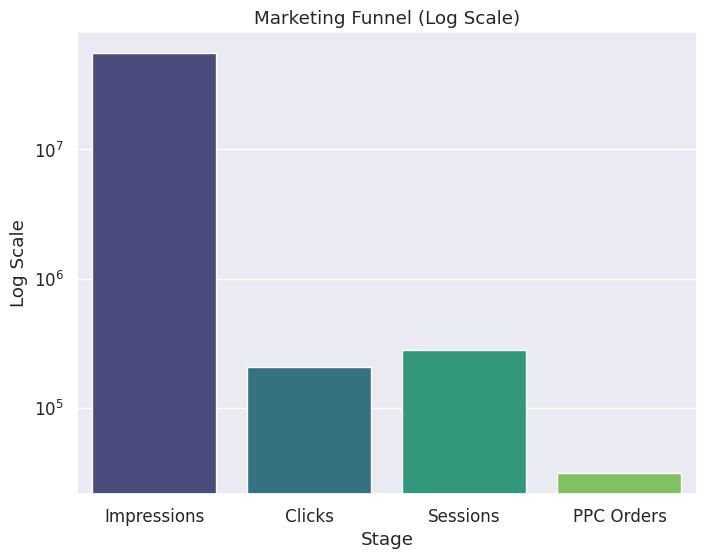

In [15]:
funnel = pd.DataFrame({
    "Stage": ["Impressions", "Clicks", "Sessions", "PPC Orders"],
    "Value": [
        df["Impressions"].sum(),
        df["Clicks"].sum(),
        df["Sessions"].sum(),
        df["PPC Orders"].sum()
    ]
})

plt.figure(figsize=(8,6))

sns.barplot(
    data=funnel,
    x="Stage",
    y="Value",
    hue="Stage",
    palette="viridis",
    legend=False
)

plt.yscale("log")
plt.title("Marketing Funnel (Log Scale)")
plt.ylabel("Log Scale")

plt.show()

PPC Efficiency by Marketplace

<Figure size 1200x600 with 0 Axes>

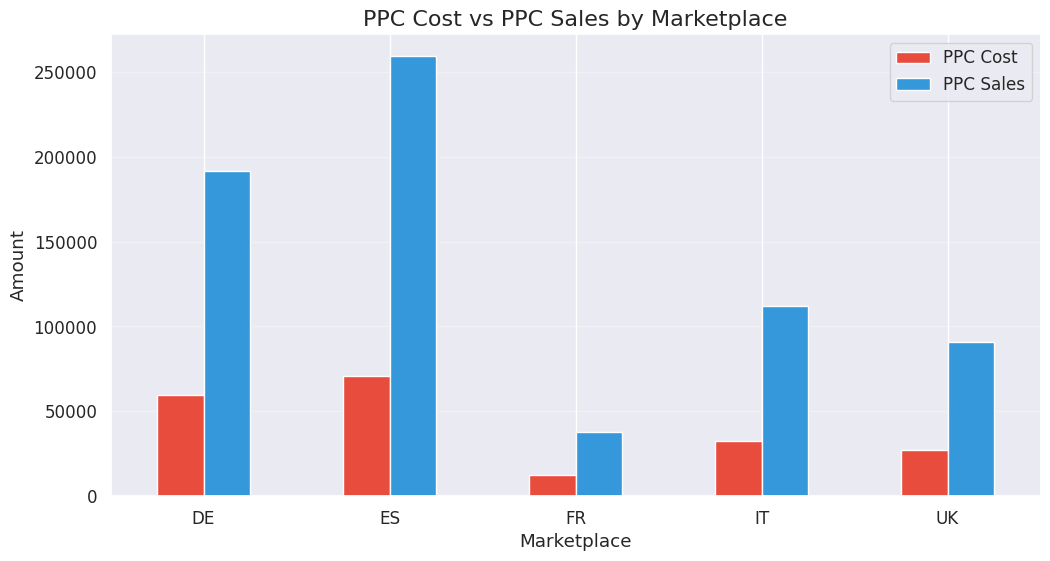

In [16]:
marketplace = df.groupby("Market Place").agg({
    "PPC Cost":"sum",
    "PPC Sales":"sum"
}).reset_index()

marketplace["PPC Cost"] = marketplace["PPC Cost"].abs()

plt.figure(figsize=(12,6))

marketplace.plot(
    x="Market Place",
    y=["PPC Cost","PPC Sales"],
    kind="bar",
    figsize=(12,6),
    color=["#E74C3C","#3498DB"]
)

plt.title("PPC Cost vs PPC Sales by Marketplace", fontsize=16)
plt.xlabel("Marketplace")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

PPC Cost vs PPC Conversion

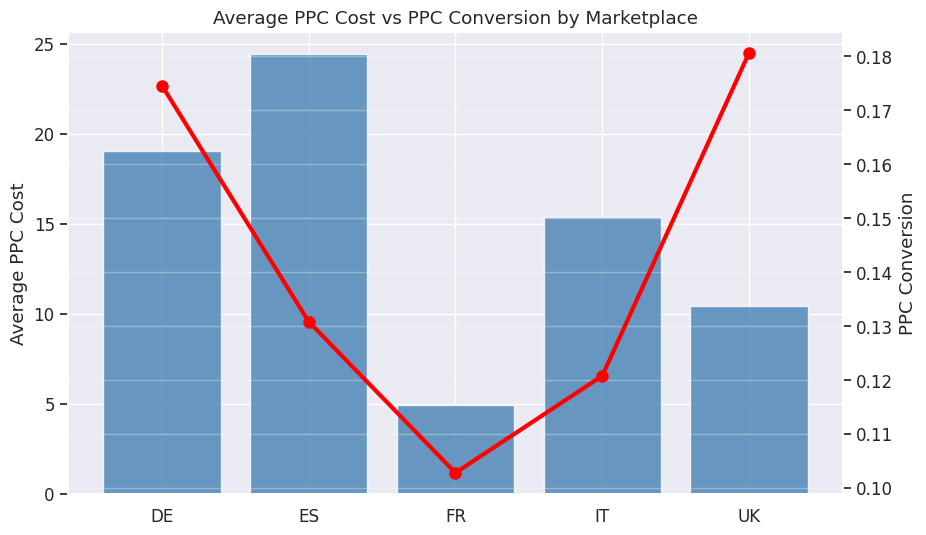

In [17]:
trend = df.groupby("Market Place").agg({
    "PPC Cost":"mean",
    "PPC Conv":"mean"
}).reset_index()

trend["PPC Cost"] = trend["PPC Cost"].abs()

fig, ax1 = plt.subplots(figsize=(10,6))

bars = ax1.bar(
    trend["Market Place"],
    trend["PPC Cost"],
    color="steelblue",
    alpha=0.8,
    label="PPC Cost"
)

ax1.set_ylabel("Average PPC Cost")

ax2 = ax1.twinx()

ax2.plot(
    trend["Market Place"],
    trend["PPC Conv"],
    color="red",
    marker="o",
    linewidth=3,
    markersize=8,
    label="PPC Conversion"
)

ax2.set_ylabel("PPC Conversion")

plt.title("Average PPC Cost vs PPC Conversion by Marketplace")

plt.grid(axis="y", alpha=0.3)

plt.show()

PPC Sales by Marketplace

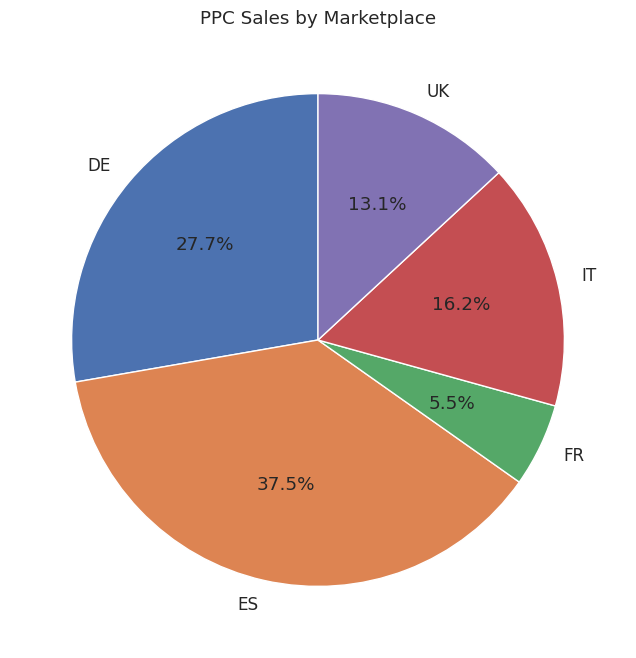

In [18]:
market_share = df.groupby("Market Place")["PPC Sales"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    market_share,
    labels=market_share.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("PPC Sales by Marketplace")

plt.show()